In [13]:
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/training_set_VU_DM.csv")

In [14]:
df.head()

,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,prop_brand_bool,prop_location_score1,prop_location_score2,prop_log_historical_price,position,price_usd,promotion_flag,srch_destination_id,srch_length_of_stay,srch_booking_window,srch_adults_count,srch_children_count,srch_room_count,srch_saturday_night_bool,srch_query_affinity_score,orig_destination_distance,random_bool,comp1_rate,comp1_inv,comp1_rate_percent_diff,comp2_rate,comp2_inv,comp2_rate_percent_diff,comp3_rate,comp3_inv,comp3_rate_percent_diff,comp4_rate,comp4_inv,comp4_rate_percent_diff,comp5_rate,comp5_inv,comp5_rate_percent_diff,comp6_rate,comp6_inv,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool
0,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,893,3,3.5,1,2.83,0.0438,4.95,27,104.77,0,23246,1,0,4,0,1,1,NaN,NaN,1,NaN,NaN,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
1,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,10404,4,4.0,1,2.20,0.0149,5.03,26,170.74,0,23246,1,0,4,0,1,1,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
2,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,21315,3,4.5,1,2.20,0.0245,4.92,21,179.80,0,23246,1,0,4,0,1,1,NaN,NaN,1,NaN,NaN,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
3,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,27348,2,4.0,1,2.83,0.0125,4.39,34,602.77,0,23246,1,0,4,0,1,1,NaN,NaN,1,NaN,NaN,NaN,-1.0,0.0,5.0,-1.0,0.0,5.0,NaN,NaN,NaN,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.0,5.0,0,NaN,0
4,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,29604,4,3.5,1,2.64,0.1241,4.93,4,143.58,0,23246,1,0,4,0,1,1,NaN,NaN,1,NaN,NaN,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0


In [4]:
df.shape

(4958347, 54)

In [6]:
# df.info() # One object that might need to be converted to Date

## Data Verification
- For each search (srch_id), it should always be on the same website (site_id)
    - The same thing has to be done for country of the visitor (visitor_location_country_id), the mean star rating of customer (visitor_location_country_id), the mean price/night of previous purchases (visitor_hist_adr_usd)
- The date and time have to be in correct format across all instances. After verification, they should be converted into pandas date data type

## Missing Values
- idea for competitor rate (comp1_rate) -> set to 0 and assume equal pricing
- for (visitor_hist_starrating) -> create a new binary feature signaling absence of previous ratings
- create a hybrid model -> one for new users that do not have any history, one for users with history
- (visitor_hist_adr_usd) -> here NA also signals no history so deal with it the same way as with (visitor_hist_starrating)
- for (prop_review_score) -> set it to 0 since it already signals an absence of reviews
- for (srch_query_affinity_score) -> fill in with very small values (< min) to indicate very low probability of being searched
- for (orig_destination_distance) -> sophisticated approach necessary. We could use the country id and destination id to calculate the distance manually

In [7]:
missing_vals = df.isnull().sum()

In [8]:
complete_features =  missing_vals[missing_vals == 0]
incomplete_features = missing_vals[missing_vals > 0]

In [9]:
print("Features that do not need any handling of missing values:")
complete_features.index.tolist()

Features that do not need any handling of missing values:


['srch_id',
 'date_time',
 'site_id',
 'visitor_location_country_id',
 'prop_country_id',
 'prop_id',
 'prop_starrating',
 'prop_brand_bool',
 'prop_location_score1',
 'prop_log_historical_price',
 'position',
 'price_usd',
 'promotion_flag',
 'srch_destination_id',
 'srch_length_of_stay',
 'srch_booking_window',
 'srch_adults_count',
 'srch_children_count',
 'srch_room_count',
 'srch_saturday_night_bool',
 'random_bool',
 'click_bool',
 'booking_bool']

In [10]:
print("Missing value features:")
incomplete_features.index.tolist()

Missing value features:


['visitor_hist_starrating',
 'visitor_hist_adr_usd',
 'prop_review_score',
 'prop_location_score2',
 'srch_query_affinity_score',
 'orig_destination_distance',
 'comp1_rate',
 'comp1_inv',
 'comp1_rate_percent_diff',
 'comp2_rate',
 'comp2_inv',
 'comp2_rate_percent_diff',
 'comp3_rate',
 'comp3_inv',
 'comp3_rate_percent_diff',
 'comp4_rate',
 'comp4_inv',
 'comp4_rate_percent_diff',
 'comp5_rate',
 'comp5_inv',
 'comp5_rate_percent_diff',
 'comp6_rate',
 'comp6_inv',
 'comp6_rate_percent_diff',
 'comp7_rate',
 'comp7_inv',
 'comp7_rate_percent_diff',
 'comp8_rate',
 'comp8_inv',
 'comp8_rate_percent_diff',
 'gross_bookings_usd']

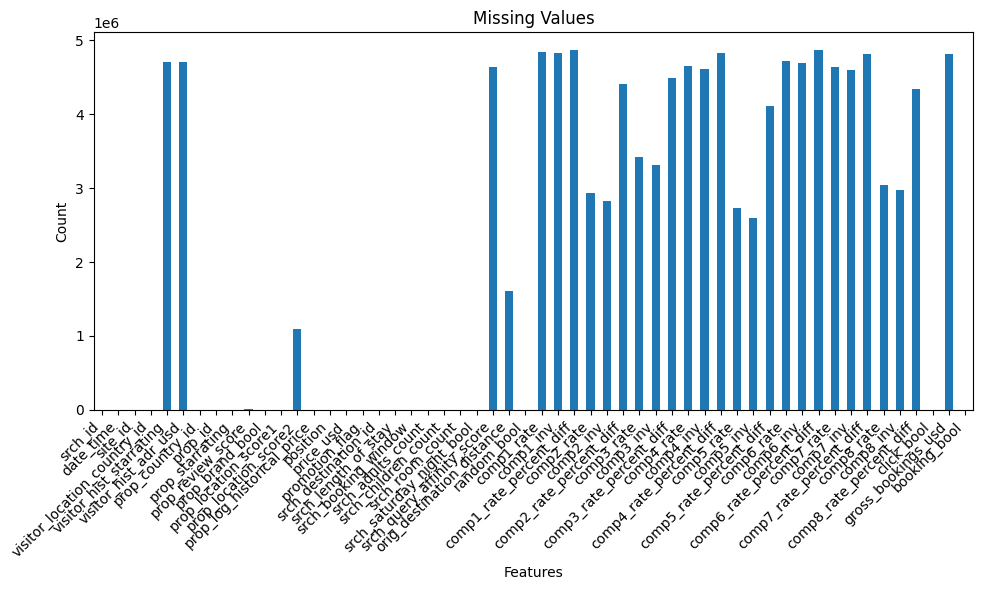

In [11]:
plt.figure(figsize=(10, 6))
missing_vals.plot(kind='bar')
plt.title('Missing Values')
plt.xlabel('Features')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### (visitor_hist_starrating)

94.92% values are missing for (visitor_hist_starrating)


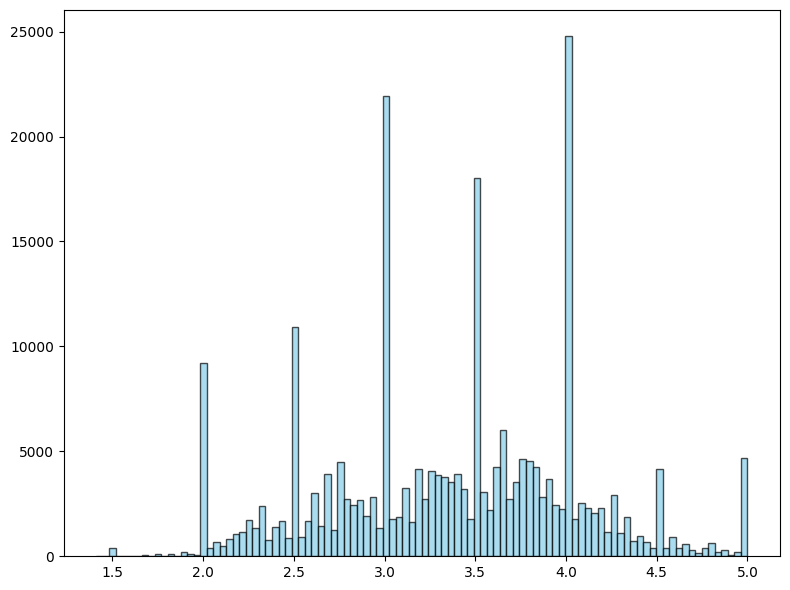

In [27]:
perc_missing = (df['visitor_hist_starrating'].isna().sum() / len(df)) * 100
print(f"{perc_missing:.2f}% values are missing for (visitor_hist_starrating)")

plt.figure(figsize=(8, 6))
plt.hist(df['visitor_hist_starrating'], bins=100, color='skyblue', edgecolor='black', alpha=0.7)
plt.tight_layout()
plt.show()

### (visitor_hist_adr_usd)

94.90% values are missing for (visitor_hist_adr_usd)


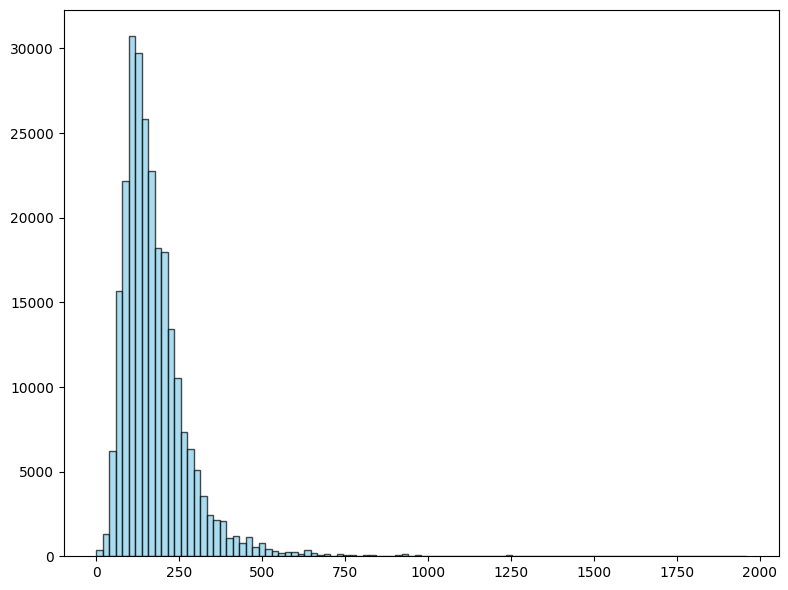

In [28]:
perc_missing = (df['visitor_hist_adr_usd'].isna().sum() / len(df)) * 100
print(f"{perc_missing:.2f}% values are missing for (visitor_hist_adr_usd)")

plt.figure(figsize=(8, 6))
plt.hist(df['visitor_hist_adr_usd'], bins=100, color='skyblue', edgecolor='black', alpha=0.7)
plt.tight_layout()
plt.show()

### (prop_review_score)

0.15% values are missing for (prop_review_score)


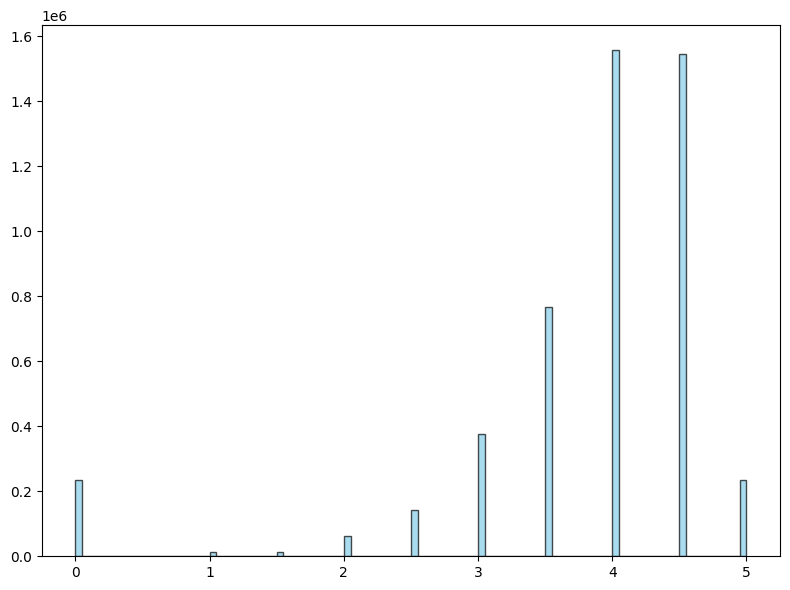

In [29]:
perc_missing = (df['prop_review_score'].isna().sum() / len(df)) * 100
print(f"{perc_missing:.2f}% values are missing for (prop_review_score)")

plt.figure(figsize=(8, 6))
plt.hist(df['prop_review_score'], bins=100, color='skyblue', edgecolor='black', alpha=0.7)
plt.tight_layout()
plt.show()

### (prop_location_score2)

21.99% values are missing for (prop_location_score2)


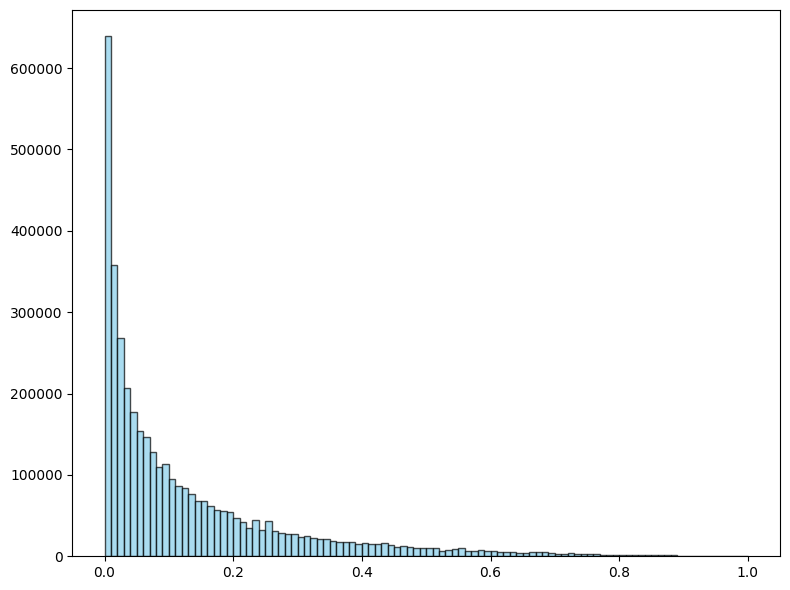

In [30]:
perc_missing = (df['prop_location_score2'].isna().sum() / len(df)) * 100
print(f"{perc_missing:.2f}% values are missing for (prop_location_score2)")

plt.figure(figsize=(8, 6))
plt.hist(df['prop_location_score2'], bins=100, color='skyblue', edgecolor='black', alpha=0.7)
plt.tight_layout()
plt.show()

### (srch_query_affinity_score)

count    317406.000000
mean        -24.146418
std          15.743238
min        -326.567500
25%         -30.774775
50%         -20.451300
75%         -13.350625
max          -2.494100
Name: srch_query_affinity_score, dtype: float64


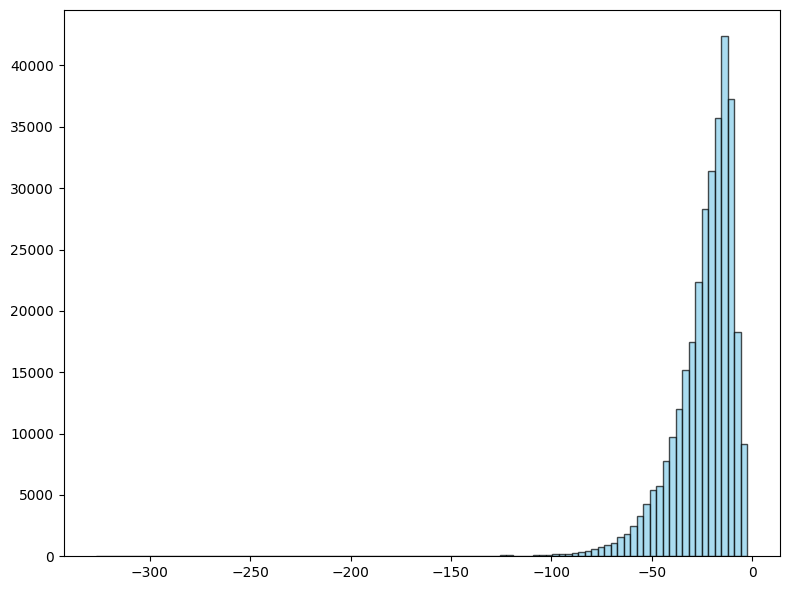

In [48]:
print(df['srch_query_affinity_score'].describe())
plt.figure(figsize=(8, 6))
plt.hist(df['srch_query_affinity_score'], bins=100, color='skyblue', edgecolor='black', alpha=0.7)
plt.tight_layout()
plt.show()

## Distributions

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
srch_id,4958347.0,166366.561096,96112.230102,1.0000,82936.000000,166507.0000,249724.000000,3.327850e+05
site_id,4958347.0,9.953133,7.646890,1.0000,5.000000,5.0000,14.000000,3.400000e+01
visitor_location_country_id,4958347.0,175.340453,65.916249,1.0000,100.000000,219.0000,219.000000,2.310000e+02
visitor_hist_starrating,251866.0,3.374334,0.692519,1.4100,2.920000,3.4500,3.930000,5.000000e+00
visitor_hist_adr_usd,252988.0,176.022659,107.254493,0.0000,109.810000,152.2400,213.490000,1.958700e+03
prop_country_id,4958347.0,173.973897,68.345248,1.0000,100.000000,219.0000,219.000000,2.300000e+02
prop_id,4958347.0,70079.179496,40609.920378,1.0000,35010.000000,69638.0000,105168.000000,1.408210e+05
prop_starrating,4958347.0,3.180525,1.051024,0.0000,3.000000,3.0000,4.000000,5.000000e+00
prop_review_score,4950983.0,3.777777,1.050329,0.0000,3.500000,4.0000,4.500000,5.000000e+00
prop_brand_bool,4958347.0,0.634699,0.481514,0.0000,0.000000,1.0000,1.000000,1.000000e+00


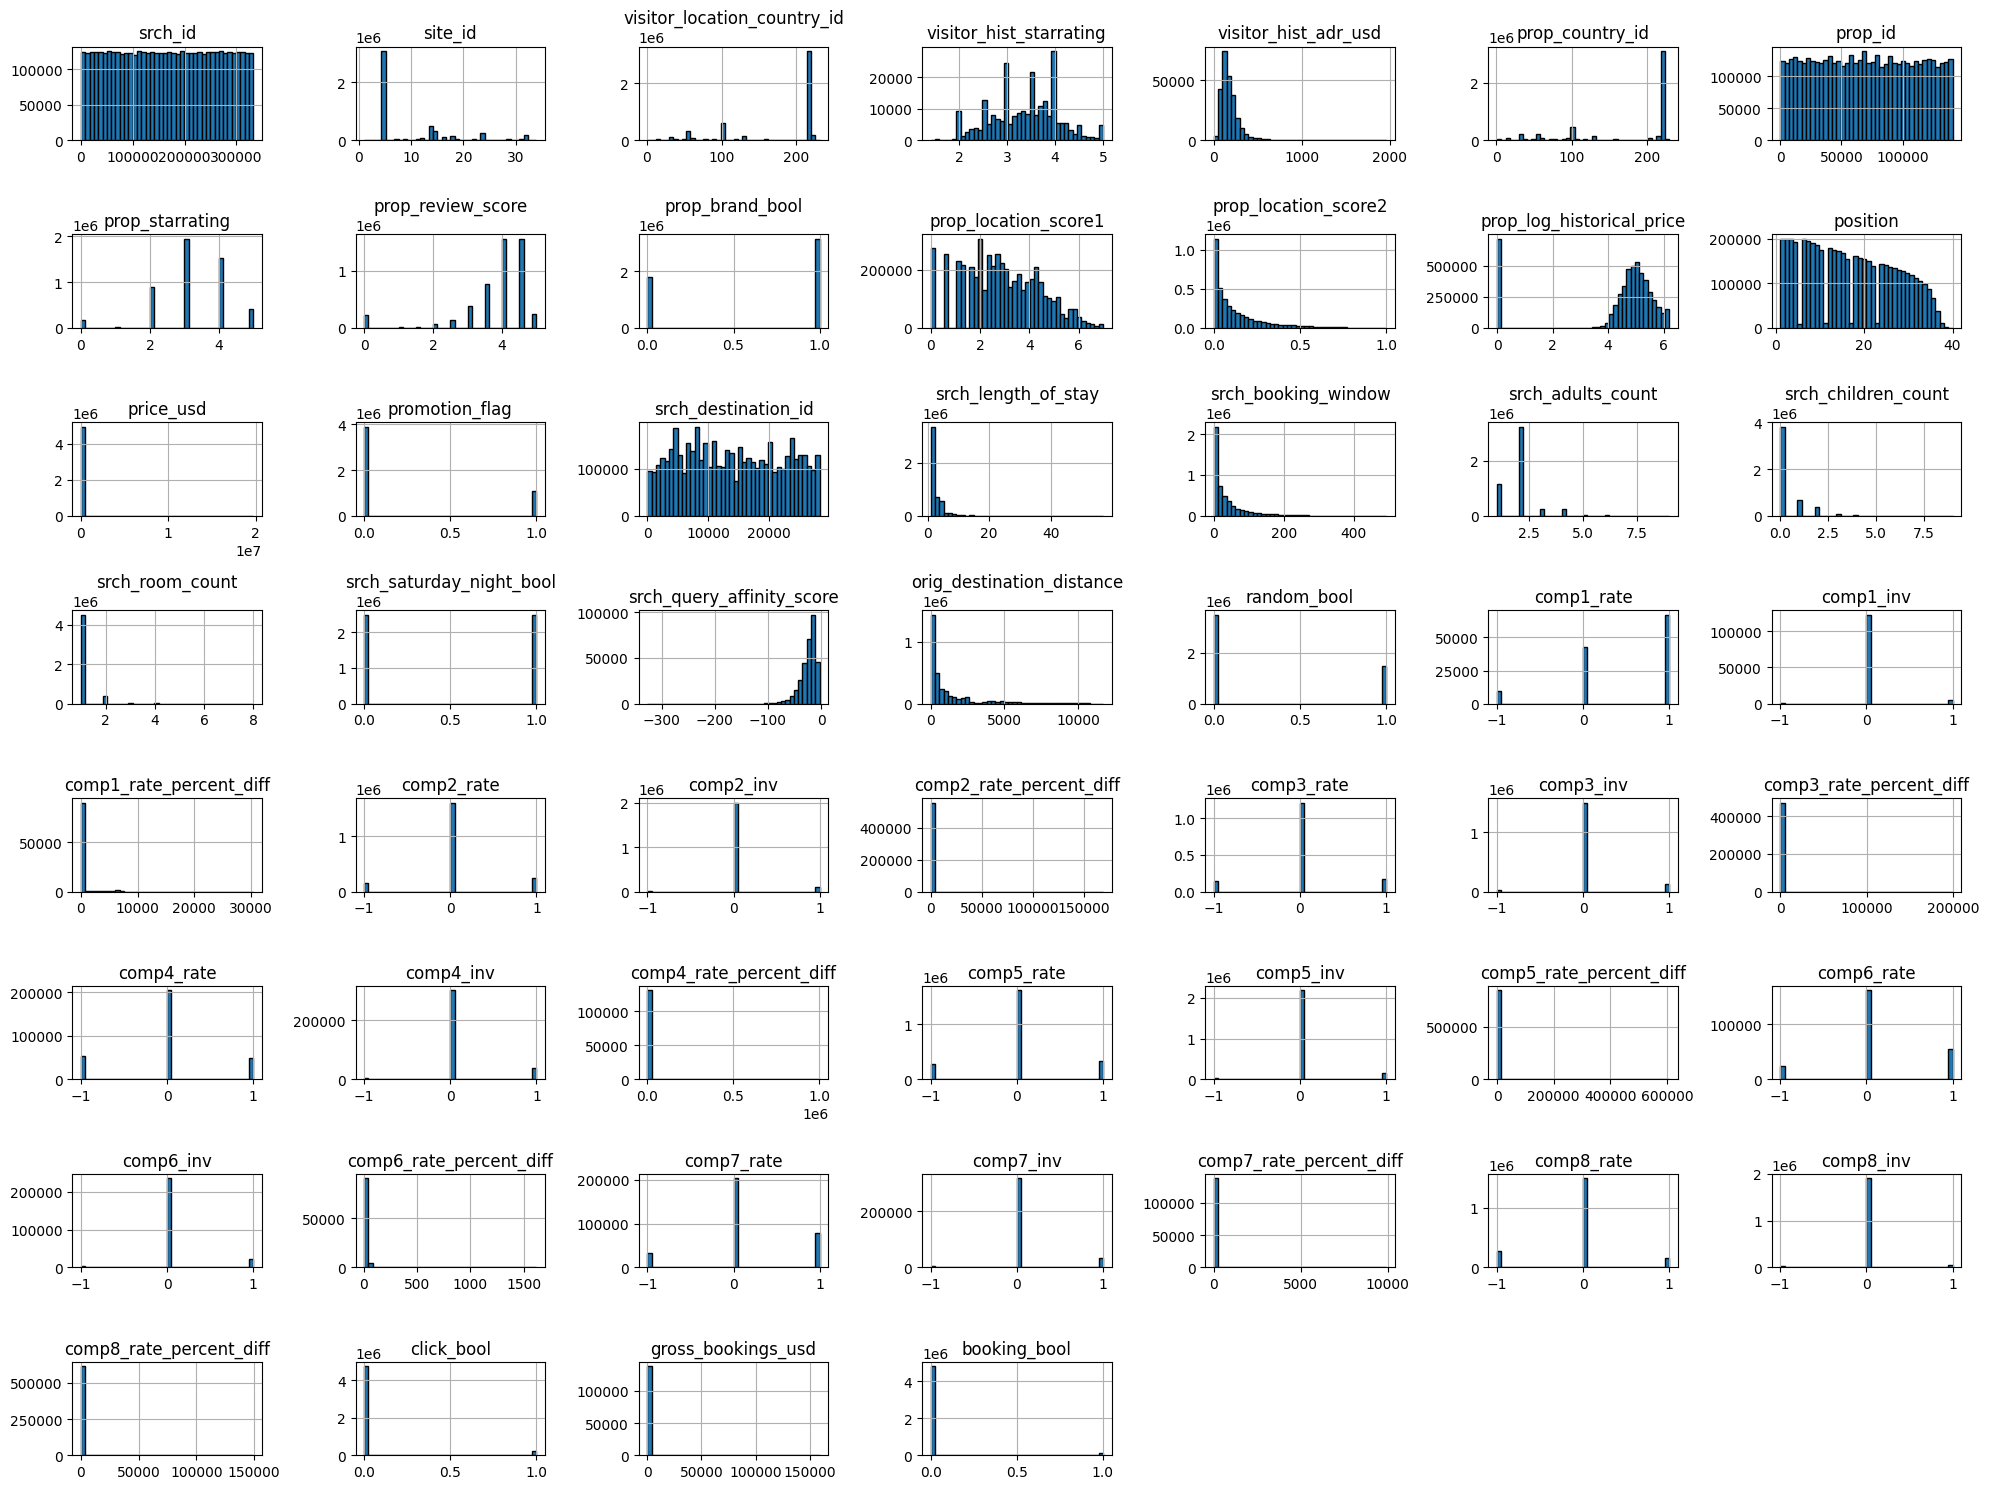

In [35]:
df.hist(figsize=(20, 15), bins=40, edgecolor='black')
plt.tight_layout()
plt.show()

In [17]:
df['comp1_rate_percent_diff']

count    94439.000000
mean       244.229916
std       1165.448634
min          2.000000
25%          7.000000
50%         10.000000
75%         16.000000
max      30389.000000
Name: comp1_rate_percent_diff, dtype: float64

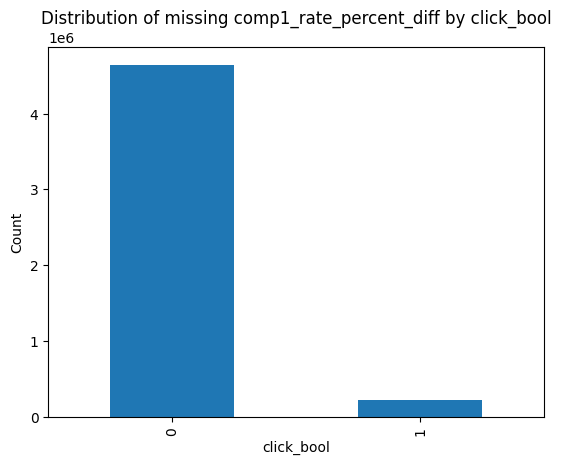

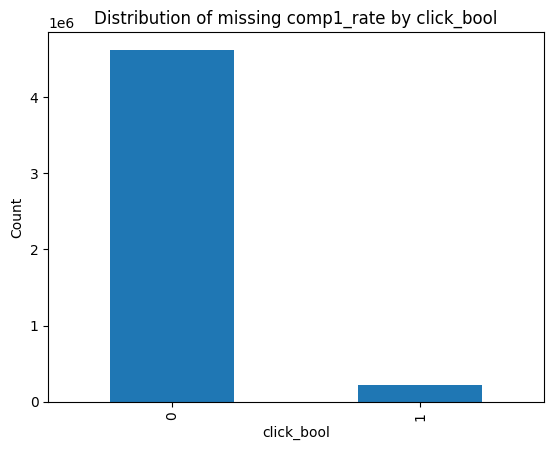

In [20]:
missing_rows = df[df['comp1_rate_percent_diff'].isna()]
missing_rows['click_bool'].value_counts().plot(kind='bar')
plt.title('Distribution of missing comp1_rate_percent_diff by click_bool')
plt.xlabel('click_bool')
plt.ylabel('Count')
plt.show()

missing_rows_rate = df[df['comp1_rate'].isna()]
missing_rows_rate['click_bool'].value_counts().plot(kind='bar')
plt.title('Distribution of missing comp1_rate by click_bool')
plt.xlabel('click_bool')
plt.ylabel('Count')
plt.show()

/var/folders/l9/ktthm47x39n329gvdz4tbyyw0000gn/T/ipykernel_26124/3438572750.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


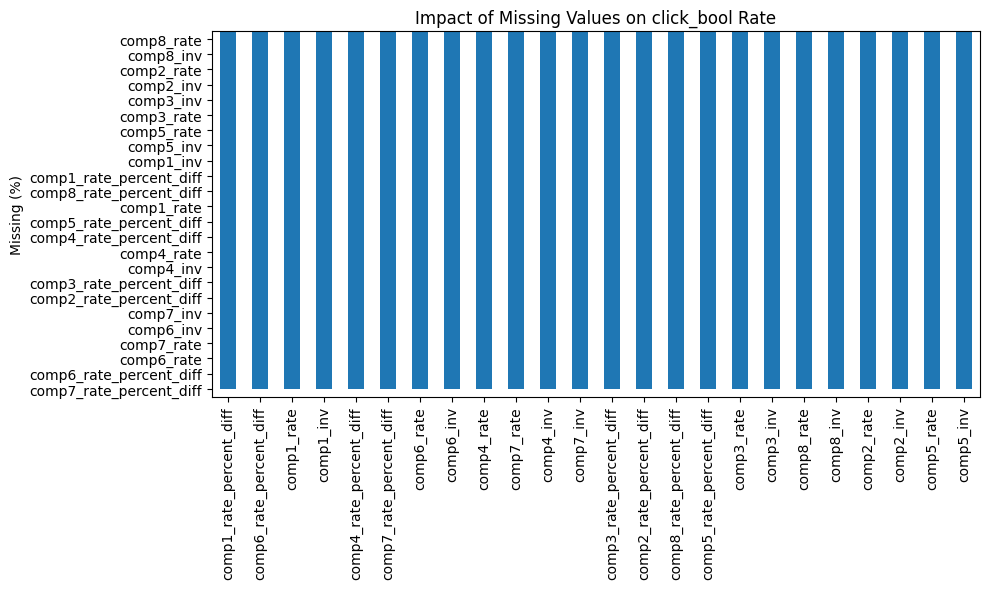

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get percentage of missing values for each competitor feature
comp_cols = [col for col in df.columns if col.startswith('comp')]
missing_pct = df[comp_cols].isna().mean().sort_values(ascending=False) * 100

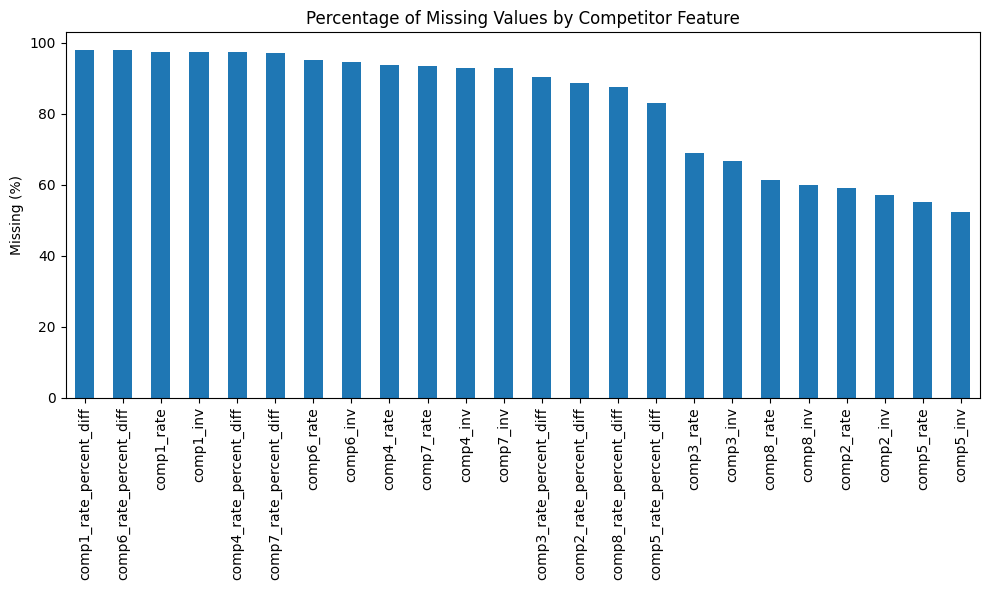

In [22]:
# 2. Plot missing percentages
plt.figure(figsize=(10, 6))
missing_pct.plot(kind='bar')
plt.title('Percentage of Missing Values by Competitor Feature')
plt.ylabel('Missing (%)')
plt.xticks(rotation=90)
plt.tight_layout()

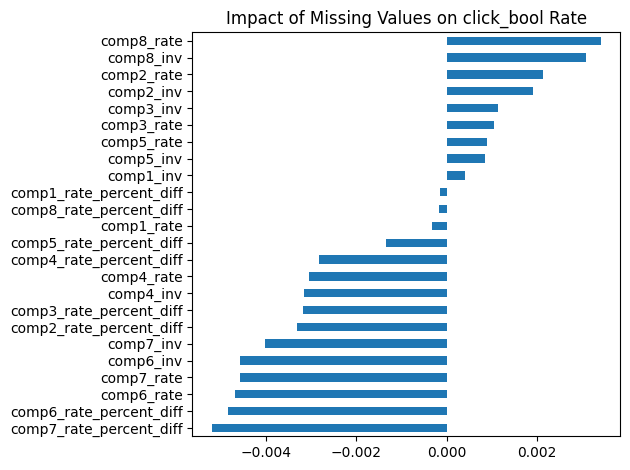

In [23]:
# 3. Check if missingness correlates with target variable
# Assuming 'click_bool' is your target - replace if different
target = 'click_bool'
missing_impact = {}

for col in comp_cols:
    # Compare target mean for missing vs. non-missing
    has_value = df[~df[col].isna()][target].mean()
    is_missing = df[df[col].isna()][target].mean()
    missing_impact[col] = {'has_value': has_value, 'is_missing': is_missing}

# Convert to DataFrame for easier viewing
impact_df = pd.DataFrame(missing_impact).T
impact_df['difference'] = impact_df['is_missing'] - impact_df['has_value']

# 4. Plot features with the largest target impact
impact_df['difference'].sort_values().plot(kind='barh')
plt.title(f'Impact of Missing Values on {target} Rate')
plt.tight_layout()